In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("used_car_price_prediction_dataset.csv")

In [3]:
df.head()

,car_id,brand,fuel_type,transmission,owner_type,manufacture_year,mileage_km,engine_cc,accidents_reported,selling_price_usd
0,100001,Hyundai,Diesel,Automatic,First,2018,55652,2200,0,16675.0
1,100002,BMW,Hybrid,Manual,First,2012,82327,1800,0,26349.0
2,100003,Kia,Hybrid,Automatic,Second,2015,117490,1200,0,11994.0
3,100004,Audi,Diesel,Manual,Second,2014,62490,1800,0,24437.0
4,100005,Hyundai,Petrol,Automatic,First,2023,70994,1200,0,22729.0


In [4]:
df.isnull().sum()

car_id                0
brand                 0
fuel_type             0
transmission          0
owner_type            0
manufacture_year      0
mileage_km            0
engine_cc             0
accidents_reported    0
selling_price_usd     0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.shape

(12000, 10)

In [7]:
df.columns

Index(['car_id', 'brand', 'fuel_type', 'transmission', 'owner_type',
       'manufacture_year', 'mileage_km', 'engine_cc', 'accidents_reported',
       'selling_price_usd'],
      dtype='object')

In [8]:
df.dtypes

car_id                  int64
brand                  object
fuel_type              object
transmission           object
owner_type             object
manufacture_year        int64
mileage_km              int64
engine_cc               int64
accidents_reported      int64
selling_price_usd     float64
dtype: object

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
car_id,12000.0,106000.500000,3464.245950,100001.0,103000.75,106000.5,109000.25,112000.0
manufacture_year,12000.0,2018.461333,4.051136,2012.0,2015.00,2018.0,2022.00,2025.0
mileage_km,12000.0,65175.491417,29240.535060,3000.0,45067.25,65102.5,85011.75,171621.0
engine_cc,12000.0,2012.133333,757.040647,1000.0,1400.00,1800.0,2500.00,3500.0
accidents_reported,12000.0,0.346917,0.585315,0.0,0.00,0.0,1.00,4.0
selling_price_usd,12000.0,26205.525333,8637.866929,3500.0,19988.00,25853.0,32203.50,56803.0


In [10]:
df.nunique()

car_id                12000
brand                    10
fuel_type                 4
transmission              2
owner_type                3
manufacture_year         14
mileage_km            11115
engine_cc                10
accidents_reported        5
selling_price_usd      9998
dtype: int64

In [11]:
df["brand"].unique()

array(['Hyundai', 'BMW', 'Kia', 'Audi', 'Nissan', 'Ford', 'Mercedes',
       'Honda', 'Toyota', 'Volkswagen'], dtype=object)

In [12]:
df["fuel_type"].unique()

array(['Diesel', 'Hybrid', 'Petrol', 'Electric'], dtype=object)

In [13]:
df["transmission"].unique()

array(['Automatic', 'Manual'], dtype=object)

In [14]:
df["owner_type"].unique()

array(['First', 'Second', 'Third'], dtype=object)

In [15]:
df["selling_price_usd"].describe()

count    12000.000000
mean     26205.525333
std       8637.866929
min       3500.000000
25%      19988.000000
50%      25853.000000
75%      32203.500000
max      56803.000000
Name: selling_price_usd, dtype: float64

<Axes: xlabel='selling_price_usd', ylabel='Count'>

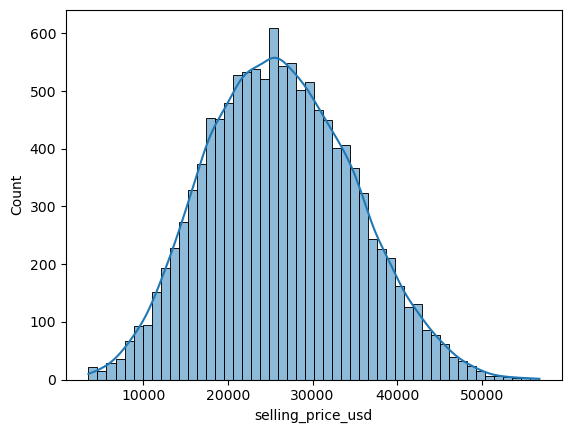

In [16]:
sns.histplot(df["selling_price_usd"],kde=True)

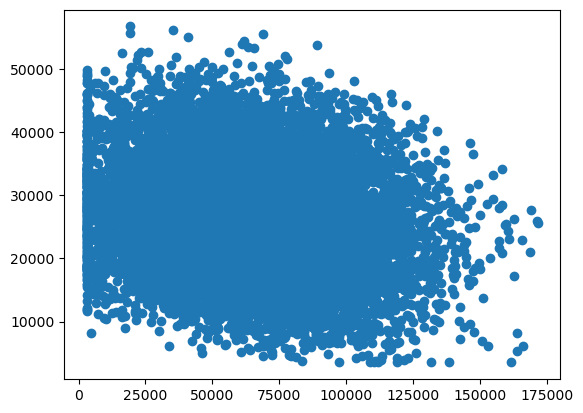

In [17]:
plt.scatter(x='mileage_km', y='selling_price_usd',data=df)
plt.show()

In [18]:
df["mileage_km"].corr(df["selling_price_usd"])

np.float64(-0.19132587797811534)

In [19]:
df["manufacture_year"].corr(df["selling_price_usd"])

np.float64(0.5412095677561011)

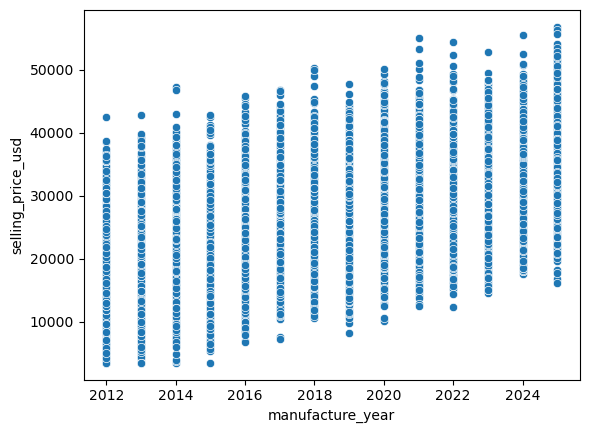

In [20]:
sns.scatterplot(x="manufacture_year",y="selling_price_usd",data=df)
plt.show()

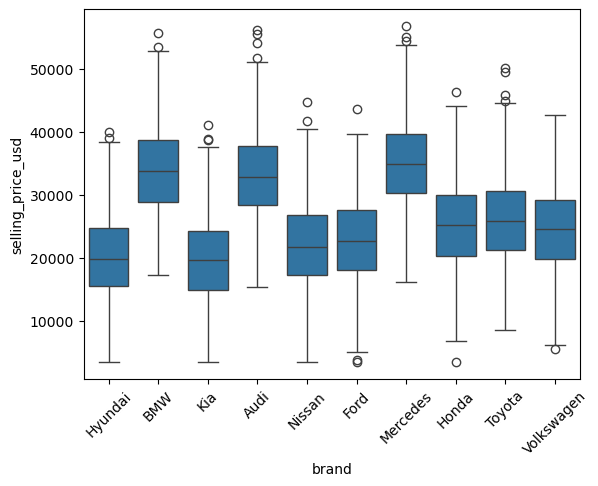

In [21]:
sns.boxplot(x='brand', y='selling_price_usd', data=df)
plt.xticks(rotation=45)
plt.show()

In [22]:
df["brand"].value_counts()

brand
Nissan        1258
Toyota        1243
Mercedes      1234
Hyundai       1210
Ford          1192
Audi          1184
Volkswagen    1181
Kia           1172
BMW           1163
Honda         1163
Name: count, dtype: int64

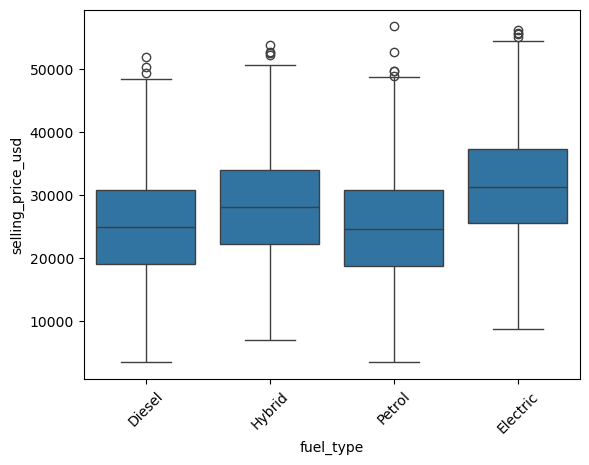

In [23]:
sns.boxplot(x='fuel_type', y='selling_price_usd', data=df)
plt.xticks(rotation=45)
plt.show()

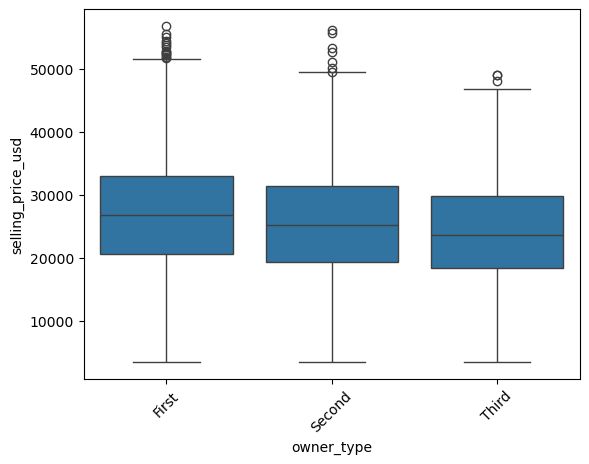

In [25]:
sns.boxplot(x='owner_type', y='selling_price_usd', data=df)
plt.xticks(rotation=45)
plt.show()

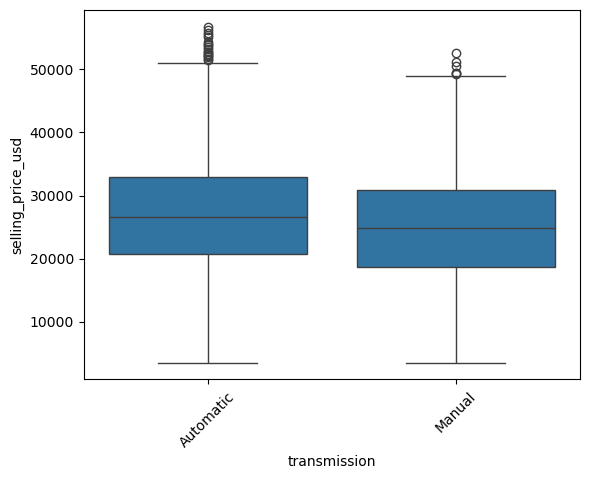

In [24]:
sns.boxplot(x='transmission', y='selling_price_usd', data=df)
plt.xticks(rotation=45)
plt.show()

In [26]:
df.corr(numeric_only=True)

,car_id,manufacture_year,mileage_km,engine_cc,accidents_reported,selling_price_usd
car_id,1.000000,-0.013868,-0.010189,0.002186,-0.012429,-0.003347
manufacture_year,-0.013868,1.000000,0.000430,-0.000244,-0.005537,0.541210
mileage_km,-0.010189,0.000430,1.000000,-0.010412,-0.000430,-0.191326
engine_cc,0.002186,-0.000244,-0.010412,1.000000,-0.016929,0.370547
accidents_reported,-0.012429,-0.005537,-0.000430,-0.016929,1.000000,-0.094236
selling_price_usd,-0.003347,0.541210,-0.191326,0.370547,-0.094236,1.000000


In [27]:
x=df.drop("selling_price_usd",axis=1)
y=df["selling_price_usd"]

In [28]:
x=x.drop("car_id",axis=1)

In [30]:
categorical_columns=x.select_dtypes(include="object").columns
categorical_columns

Index(['brand', 'fuel_type', 'transmission', 'owner_type'], dtype='object')

In [31]:
num_columns=x.select_dtypes(include=["int64","float64"]).columns
num_columns

Index(['manufacture_year', 'mileage_km', 'engine_cc', 'accidents_reported'], dtype='object')

In [33]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [35]:
cat_cols = x.select_dtypes('object').columns
num_cols = x.select_dtypes('number').columns

In [37]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

In [38]:
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

In [39]:
print(x_train_processed.shape)
print(x_test_processed.shape)

(9600, 23)
(2400, 23)


In [40]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [41]:
model.fit(x_train_processed,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
y_pred=model.predict(x_test_processed)

In [43]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print(mae)

1483.4852247314834


In [44]:
from sklearn.metrics import mean_squared_error
rmse = mean_squared_error(y_test, y_pred) ** 0.5
print(rmse)

1855.7770667421687


In [45]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(r2)

0.9530649001307956


In [46]:
train_r2 = r2_score(y_train, model.predict(x_train_processed))
print(train_r2)

0.9556805000528061


In [47]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'Elastic Net': ElasticNet(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

for name, model in models.items():
    model.fit(x_train_processed, y_train)
    pred = model.predict(x_test_processed)
    print(name)
    print("MAE:", mean_absolute_error(y_test, pred))
    print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)
    print("R2:", r2_score(y_test, pred))
    print()

Ridge
MAE: 1483.570259438069
RMSE: 1855.8298151684014
R2: 0.9530622319354797

Lasso
MAE: 1483.753370613176
RMSE: 1855.889657161726
R2: 0.9530592048315216

Elastic Net
MAE: 4299.259473167144
RMSE: 5124.9688941835
R2: 0.6420448567852403

Decision Tree
MAE: 2815.6045833333333
RMSE: 3599.2742549135282
R2: 0.823446626927203

Random Forest
MAE: 1910.8222666666663
RMSE: 2393.217040659114
R2: 0.9219432774150803

Gradient Boosting
MAE: 1750.4289884345812
RMSE: 2190.520917286043
R2: 0.9346055414156581



In [48]:
results = []
for name, model in models.items():
    pred = model.predict(x_test_processed)
    
    results.append([
        name,
        mean_absolute_error(y_test, pred),
        mean_squared_error(y_test, pred) ** 0.5,
        r2_score(y_test, pred)
    ])

results_df = pd.DataFrame(
    results,
    columns=['Model', 'MAE', 'RMSE', 'R2']
)

results_df.sort_values('R2', ascending=False)

,Model,MAE,RMSE,R2
0,Ridge,1483.570259,1855.829815,0.953062
1,Lasso,1483.753371,1855.889657,0.953059
5,Gradient Boosting,1750.428988,2190.520917,0.934606
4,Random Forest,1910.822267,2393.217041,0.921943
3,Decision Tree,2815.604583,3599.274255,0.823447
2,Elastic Net,4299.259473,5124.968894,0.642045


In [54]:
from sklearn.model_selection import cross_val_score
ridge = Ridge()
scores = cross_val_score(
    ridge,
    x_train_processed,
    y_train,
    cv=5,
    scoring='r2'
)

print(scores)
print(scores.mean())

[0.95364192 0.95676887 0.95649471 0.95699362 0.95324593]
0.9554290105466707


In [55]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}
grid = GridSearchCV(
    Ridge(),
    param_grid,
    cv=5,
    scoring='r2'
)

grid.fit(x_train_processed, y_train)

print("Best Alpha:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

Best Alpha: {'alpha': 0.01}
Best CV R2: 0.9554297247993941


In [56]:
best_model = grid.best_estimator_

y_pred_ridge = best_model.predict(x_test_processed)

print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("RMSE:", mean_squared_error(y_test, y_pred_ridge) ** 0.5)
print("R2:", r2_score(y_test, y_pred_ridge))

MAE: 1483.4860349718838
RMSE: 1855.777508302624
R2: 0.9530648777954764


In [57]:
train_r2 = r2_score(y_train, best_model.predict(x_train_processed))
test_r2 = r2_score(y_test, y_pred_ridge)

print("Train R2:", train_r2)
print("Test R2:", test_r2)

Train R2: 0.9556805000067895
Test R2: 0.9530648777954764


In [58]:
coefficients = pd.Series(
    best_model.coef_,
    index=preprocessor.get_feature_names_out()
)
print(coefficients.sort_values(ascending=False))

cat__brand_Mercedes              8972.089492
cat__brand_BMW                   7730.639546
cat__brand_Audi                  6439.926941
cat__fuel_type_Electric          4092.292104
cat__owner_type_First            1289.828859
remainder__manufacture_year      1148.010235
cat__fuel_type_Hybrid             953.729950
cat__transmission_Automatic       886.968540
remainder__engine_cc                4.239779
remainder__mileage_km              -0.055126
cat__brand_Toyota                -133.325090
cat__owner_type_Second           -173.925420
cat__brand_Honda                 -506.302422
cat__transmission_Manual         -886.968540
cat__owner_type_Third           -1115.903434
remainder__accidents_reported   -1165.113717
cat__brand_Volkswagen           -1992.815081
cat__fuel_type_Diesel           -2521.389966
cat__fuel_type_Petrol           -2524.632089
cat__brand_Ford                 -3477.557409
cat__brand_Nissan               -4560.319640
cat__brand_Hyundai              -6026.469579
cat__brand

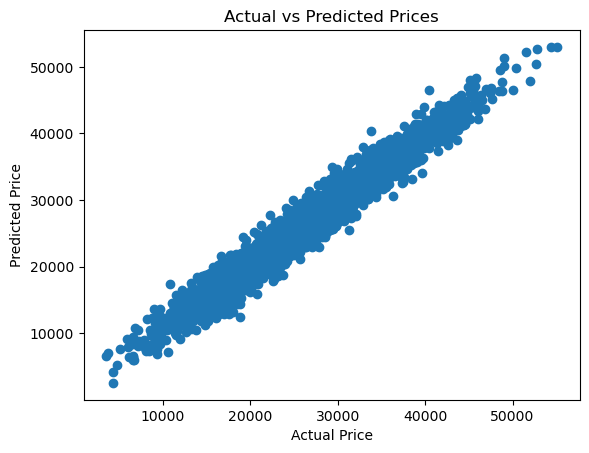

In [59]:
plt.scatter(y_test, y_pred_ridge)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.show()

In [60]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=0.01))
])

final_pipeline.fit(x_train, y_train)

y_pred_final = final_pipeline.predict(x_test)

mae = mean_absolute_error(y_test, y_pred_final)
rmse = mean_squared_error(y_test, y_pred_final) ** 0.5
r2 = r2_score(y_test, y_pred_final)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

joblib.dump(final_pipeline, 'car_price_model.pkl')

MAE: 1483.4860349718838
RMSE: 1855.777508302624
R2: 0.9530648777954764


['car_price_model.pkl']

In [61]:
import os
print(os.path.exists('car_price_model.pkl'))

True
